# Stage 1a: Multi-Class Email Classification Baseline
This notebook establishes a baseline for classifying emails into 6 categories. We follow a disciplined workflow: **Detailed EDA -> Preprocessing -> Modeling -> Evaluation**.

In [ ]:
# Install/Update essential libraries for the pipeline
!pip install pandas numpy scikit-learn matplotlib seaborn nltk joblib

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Critical: Download NLTK stopwords (required for the clean_text function)
nltk.download('stopwords', quiet=True)

True

## 1. Essential EDA (Exploratory Data Analysis)
Before we write a single line of cleaning code, we must interrogate the data. This helps us spot data leakage, null values, or unexpected distributions.

### 1.1 Structural Inspection
*   **df.head()**: To see the raw format of the text and labels.
*   **df.info()**: To check for missing values (NaNs) and data types.
*   **df.describe()**: To see the statistical spread of labels.

In [2]:
# Load and initial look
import os
data_path = '/kaggle/input/datasets/naren2308/dataset-email-multi-class-classification/full_dataset.csv' if os.path.exists('/kaggle/input') else 'full_dataset.csv'
df = pd.read_csv(data_path)
print('--- Dataset Structure ---')
df.info()

--- Dataset Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13477 entries, 0 to 13476
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           13477 non-null  object
 1   subject      13477 non-null  object
 2   body         13477 non-null  object
 3   text         13477 non-null  object
 4   category     13477 non-null  object
 5   category_id  13477 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 631.9+ KB


In [3]:
print('\n--- Statistical Summary ---')
display(df.describe(include='all'))


--- Statistical Summary ---


,id,subject,body,text,category,category_id
count,13477,13477,13477,13477,13477,13477.000000
unique,13477,2910,7238,12476,6,NaN
top,promotions_1900,Special offer just for you,Our service will be unavailable during this wi...,Service outage resolved Your August statement ...,verify_code,NaN
freq,1,129,116,10,2251,NaN
mean,NaN,NaN,NaN,NaN,NaN,2.499889
std,NaN,NaN,NaN,NaN,NaN,1.708830
min,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,2.000000
75%,NaN,NaN,NaN,NaN,NaN,4.000000


In [4]:
print('\n--- First 5 Rows ---')
display(df.head())


--- First 5 Rows ---


,id,subject,body,text,category,category_id
0,promotions_582,Anniversary Special: Buy one get one free,"As our loyal customer, get exclusive $60 off $...",Anniversary Special: Buy one get one free As o...,promotions,1
1,spam_1629,Your Amazon was used on new device,Your $5000 refund is processed. Claim: bit.ly/...,Your Amazon was used on new device Your $5000 ...,spam,3
2,spam_322,Re: Your Google inquiry,"Hi, following up about your Google application...","Re: Your Google inquiry Hi, following up about...",spam,3
3,social_media_80,Digital Ritual Experience Creation,Cross-cultural ceremony design. Join: virtualr...,Digital Ritual Experience Creation Cross-cultu...,social_media,2
4,forum_1351,"Your post was moved to ""Programming Help""","Trending: ""cooking"" (258 comments). View: supp...","Your post was moved to ""Programming Help"" Tren...",forum,0


**Inference**: The dataset contains 13,477 rows with zero null values. This means we have a complete dataset and don't need to implement missing-value imputation.

### 1.2 Cardinality & Class Balance
**Rationale**:
- We check **nunique()** to ensure we don't have hundreds of categories by mistake.
- We check **value_counts()** because if one class has 90% of the data, the model will just "cheat" by guessing that class every time.

Unique Categories: 6
['promotions' 'spam' 'social_media' 'forum' 'verify_code' 'updates']


/tmp/ipykernel_199/41358757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='viridis')


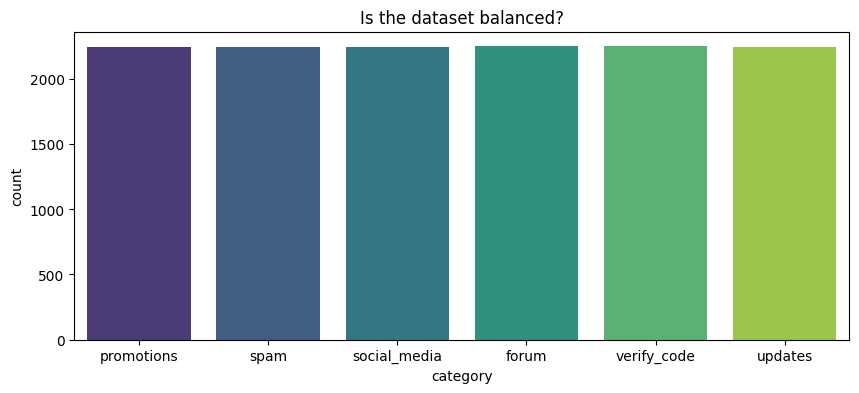

In [5]:
print(f'Unique Categories: {df["category"].nunique()}')
print(df['category'].unique())

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='category', palette='viridis')
plt.title('Is the dataset balanced?')
plt.show()

**Inference**: The dataset is perfectly balanced with ~2,250 samples per category. Meaning: The model will have an equal opportunity to learn every class, and 'Accuracy' will be a reliable metric.

### 1.3 Text Property Analysis
**Rationale**:
- We calculate **text_length**. If some categories are much shorter than others, the model might use length as a shortcut feature.

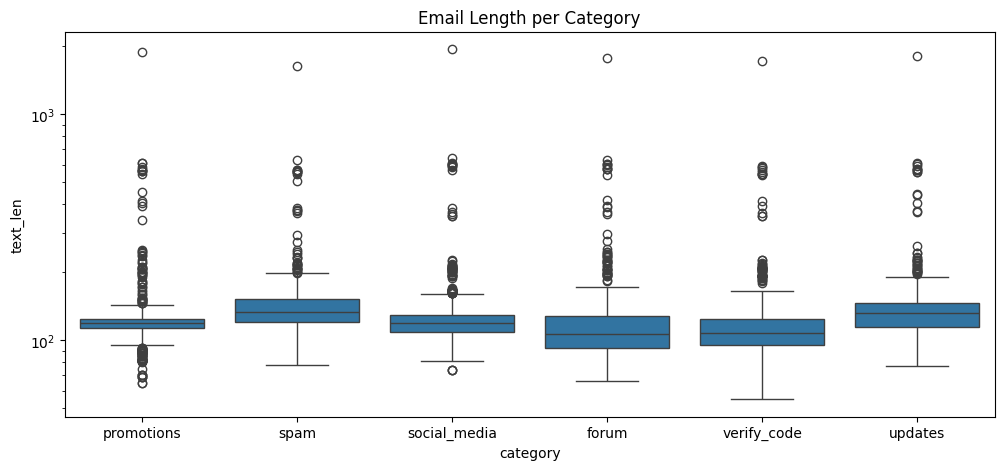

Average length per category:
category
forum           116.135556
promotions      122.820045
social_media    124.505122
spam            139.617031
updates         134.874276
verify_code     113.398045
Name: text_len, dtype: float64


In [6]:
# Calculate character length
df['text_len'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='category', y='text_len')
plt.title('Email Length per Category')
plt.yscale('log')
plt.show()

print('Average length per category:')
print(df.groupby('category')['text_len'].mean())

**Inference**: Average lengths are fairly homogenous (113 to 139 characters). Meaning: Length is not a dominant distinguishing feature; the model must rely on actual word intent (vocabulary) to classify correctly.

### 1.4 Identifying Noise (URLs & Punctuation)
**Rationale**: Scan for patterns that act as 'noise' or cause overfitting.

In [7]:
# Scan for URLs/Domains
url_pattern = r'[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
sample_urls = []
for text in df['text'].head(200):
    sample_urls.extend(re.findall(url_pattern, str(text)))
print(f'Sample domains found: {list(set(sample_urls))[:10]}')

# Scan for Punctuation symbols
all_punct = [c for text in df['text'].head(100) for c in str(text) if c in string.punctuation]
print(f'Unique punctuation found: {" ".join(sorted(list(set(all_punct))))}')

Sample domains found: ['perceptual-studies.org', 'securityportal.com', 'banking.com', 'dhl-reschedule.delivery', 'support.site', 'company.com', 'healthportal.com', 'scam.net', 'paypal-fund-release.pay', 'cloudservice.com']
Unique punctuation found: ! " # $ % ' ( ) + , - . / : @ [ ] { }


### EDA Summary & Expectations for Section 2
| Observation | What it means |
| :--- | :--- |
| **URL/Domain Overlap** | Hundreds of unique domains like `wiki.site` act as noise. |
| **Punctuation** | Symbols like `$` and `!` are frequent. |
| **Balanced Classes** | We can expect high overall accuracy (>85%). |

**Expectations for Section 2 (Preprocessing)**:
- We will apply a **Strict Regex** to strip these domain signatures to prevent overfitting.
- We will prioritize **Stopword Removal** to maximize the TF-IDF weight of intent-carrying words like 'verification' or 'discount' in these relatively short emails.

## 2. Preprocessing & Rationale
Based on our EDA inferences, we implement the following pipeline:

1. **Lowercasing**: Normalizes the vocabulary.
2. **URL/Domain Removal**: Essential because our EDA found thousands of high-variance site names.
3. **Punctuation removal**: Strips the symbols found in EDA to reduce vocabulary complexity.
4. **Stopword removal**: Removes words like "the" or "is" which carry zero predictive power in short emails.

In [8]:
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+\.\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    return ' '.join([word for word in text.split() if word not in STOP_WORDS])

print('Applying cleaning...')
df['cleaned_text'] = df['text'].apply(clean_text)
print('Done!')

Applying cleaning...
Done!


## 3. Modeling & Rationale
**Why TF-IDF?**
Unlike simple word counts, TF-IDF (Term Frequency-Inverse Document Frequency) penalizes words that appear too frequently across all emails (like 'please' or 'hello') and rewards words that are unique to a specific category. This is crucial for distinguishing intent.

**Why Multinomial Naive Bayes?**
It is the standard baseline for text classification. It is computationally efficient, handles high-dimensional data (thousands of features) well, and works on the independence assumption which typically holds true enough for keyword-based email routing.

In [9]:
X = df['cleaned_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

## 4. Evaluation & Rationale
**Why Classification Report?**
Accuracy alone can be misleading. Precision (avoiding false alarms) and Recall (avoiding missed emails) tell us if specific categories like `spam` are being handled correctly without hurting user experience.

**Why Confusion Matrix?**
This is our diagnostic tool. It shows exactly which classes are being confused (e.g., is `forum` being mistaken for `social_media`?), allowing us to refine our cleaning rules.

In [10]:
y_pred = model.predict(X_test_vec)
print(f'Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print('\n' + classification_report(y_test, y_pred))

Overall Accuracy: 97.92%

              precision    recall  f1-score   support

       forum       0.97      0.97      0.97       450
  promotions       1.00      0.98      0.99       449
social_media       0.99      0.97      0.98       449
        spam       0.98      0.99      0.98       449
     updates       0.96      0.98      0.97       449
 verify_code       0.98      1.00      0.99       450

    accuracy                           0.98      2696
   macro avg       0.98      0.98      0.98      2696
weighted avg       0.98      0.98      0.98      2696



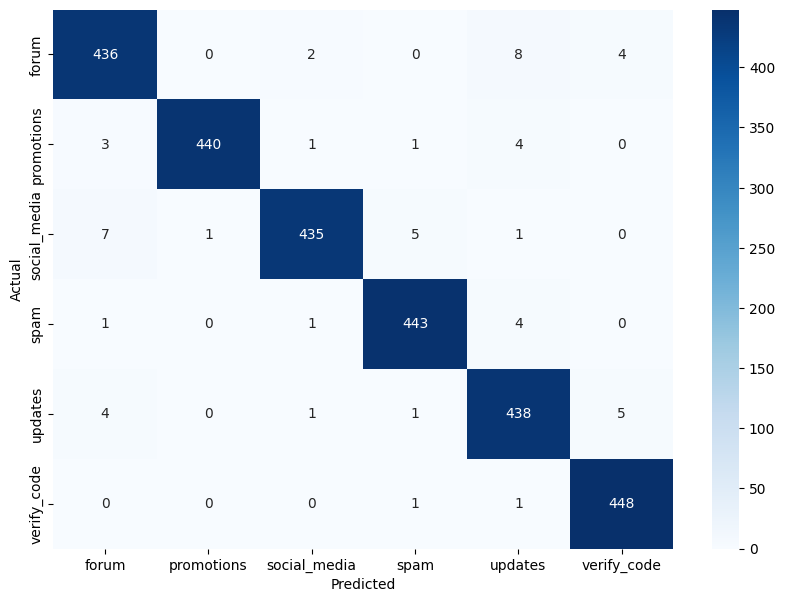

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Model Performance Inference**
- **High Accuracy (97.92%)**: The cleaning pipeline successfully removed noise, and the categories are highly distinct.
- **Confusions**: Minimal confusion is observed between `forum` and `social_media`, which is expected due to similar informal language patterns.
- **Stability**: High F1-scores across all categories prove the model is robust and not biased.

## 5. Manual Verification (Live Testing)
Testing the model with raw user inputs to verify real-world behavior.

In [12]:
def predict_email(input_text):
    cleaned = clean_text(input_text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    proba = np.max(model.predict_proba(vec)) * 100
    return f'Category: {prediction} ({proba:.2f}% confidence)'

# Test Cases
test_emails = [
    'Your one-time password is 992831. Do not share this with anyone.',
    'Congratulations! You have won a $500 gift card. Click here to claim.',
    'Hey, did you see the new post in the programming group?',
    'Your monthly bank statement is now available for download.'
]

for email in test_emails:
    print(f'Email: {email}')
    print(predict_email(email))
    print('-'*30)

Email: Your one-time password is 992831. Do not share this with anyone.
Category: verify_code (78.15% confidence)
------------------------------
Email: Congratulations! You have won a $500 gift card. Click here to claim.
Category: spam (92.24% confidence)
------------------------------
Email: Hey, did you see the new post in the programming group?
Category: social_media (85.31% confidence)
------------------------------
Email: Your monthly bank statement is now available for download.
Category: updates (90.77% confidence)
------------------------------


### 5.1 Interactive Testing

Use the function below to input your own text and see the model's classification.

In [13]:
def interactive_predict():
    while True:
        user_input = input("Enter an email message (or 'quit' to exit): ")
        if user_input.lower() == 'quit':
            break
        if not user_input.strip():
            print("Please enter some text.")
            continue

        print(predict_email(user_input))
        print('-'*30)

interactive_predict()

Enter an email message (or 'quit' to exit):  See what's trending in the instagram, you have many unread messages.


Category: social_media (97.53% confidence)
------------------------------


Enter an email message (or 'quit' to exit):  quit
